# Error Models & PSF Degradation

Real telescopes have rough surfaces, misaligned facets and residual figure
errors. IACTrace applies these as functional operations that each return a new
telescope, so they compose freely. 

In [1]:
%matplotlib inline
import jax
import jax.numpy as jnp
import matplotlib.pyplot as plt

from iactrace import Telescope
from iactrace.analysis import FlatFocalPlane

telescope = Telescope.from_yaml(
    "../../configs/HESS/CT3.yaml", n_samples=256, key=jax.random.key(0)
)
on_axis = jnp.array([[0.0, 0.0, -1.0]])


def spot(tel):
    """Focal-plane hit positions [mm] about the centroid, weights, and RMS radius [mm]."""
    hits = FlatFocalPlane().intersect(tel.render(on_axis, jnp.array([1.0]), "parallel"))
    m = hits.alive
    xy = hits.xy_local[m] * 1000.0
    w = hits.values[m]
    centroid = (w[:, None] * xy).sum(0) / w.sum()
    xy = xy - centroid
    rms = float(jnp.sqrt((w * (xy ** 2).sum(1)).sum() / w.sum()))
    return xy, w, rms

## Baseline PSF

The H.E.S.S. I Davies–Cotton design has an intrinsic on-axis spot size even if perfect. This is caused by us simulating a source at infinity, whose focal distance is 15m. The surface of the science camera (where our focal plane is defined) is at 15.028m though, causing the ring shaped PSF due to being technically slightly out of focus.

ideal RMS spot radius: 10.22 mm


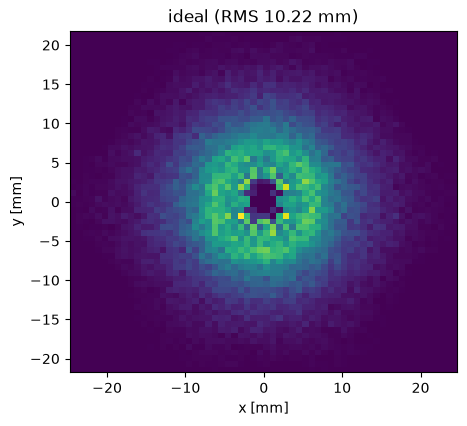

In [2]:
xy, w, rms0 = spot(telescope)
print(f"ideal RMS spot radius: {rms0:.2f} mm")

fig, ax = plt.subplots(figsize=(5, 5))
ax.hist2d(xy[:, 0], xy[:, 1], bins=60, weights=w)
ax.set(title=f"ideal (RMS {rms0:.2f} mm)", xlabel="x [mm]", ylabel="y [mm]")
ax.set_aspect("equal")
plt.show()

## Surface roughness sweep

Roughness scatters the surface normals, broadening the PSF. The RMS spot radius
grows smoothly with the roughness sigma (arcseconds).

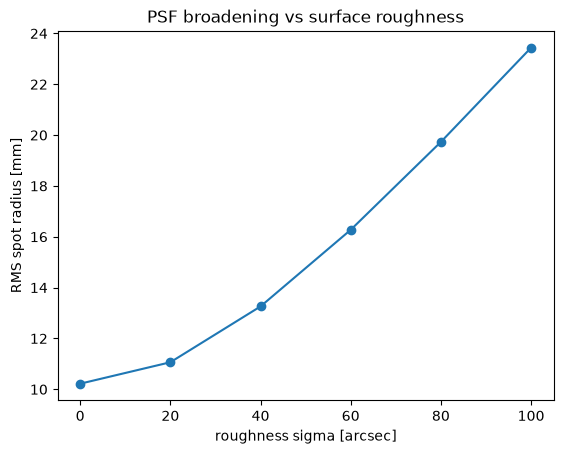

In [3]:
sigmas = [0, 20, 40, 60, 80, 100]
rms_vs_sigma = [spot(telescope.apply_roughness(0, s))[2] for s in sigmas]

plt.plot(sigmas, rms_vs_sigma, "o-")
plt.xlabel("roughness sigma [arcsec]")
plt.ylabel("RMS spot radius [mm]")
plt.title("PSF broadening vs surface roughness")
plt.show()

## Types of imperfections

We compare a few imperfections applying to mirrors, such as an increased microroughness, a large average mirror misalignment and a coma applied to each mirror.

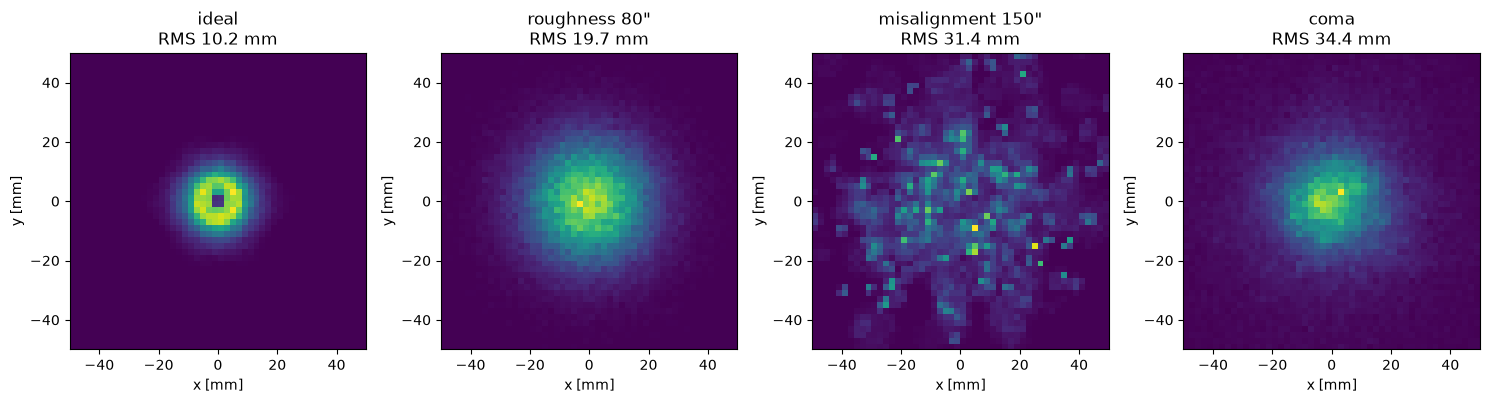

In [4]:
key = jax.random.key(7)
variants = [
    ("ideal", telescope),
    ('roughness 80"', telescope.apply_roughness(0, 80.0)),
    ('misalignment 150"', telescope.apply_misalignment(0, 150.0, 150.0, key)),
    ("coma", telescope.apply_coma(0, 3e-5, key)),
]

rng = [[-50, 50], [-50, 50]]
fig, ax = plt.subplots(1, 4, figsize=(15, 4))
for a, (title, tel) in zip(ax, variants, strict=False):
    xy, w, rms = spot(tel)
    a.hist2d(xy[:, 0], xy[:, 1], bins=50, weights=w, range=rng)
    a.set(title=f"{title}\nRMS {rms:.1f} mm", xlabel="x [mm]", ylabel="y [mm]")
    a.set_aspect("equal")
fig.tight_layout()
plt.show()